In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import numpy as np

# Updated axial coordinates for hexagons with tight spacing:
#   1  2  3
# 4  5  6  7
#   8  9 10
# 11 12 13 14
#   15 16 17

coord = [
    [-1, 1], [0, 1], [1, 1],  # Row 1: (1 2 3)
    [-1.5, 0], [-0.5, 0], [0.5, 0], [1.5, 0],  # Row 2: (4 5 6 7)
    [-1, -1], [0, -1], [1, -1],  # Row 3: (8 9 10)
    [-1.5, -2], [-0.5, -2], [0.5, -2], [1.5, -2],  # Row 4: (11 12 13 14)
    [-1, -3], [0, -3], [1, -3]  # Row 5: (15 16 17)
]

labels = [
    ['1'], ['2'], ['3'],  # Row 1
    ['4'], ['5'], ['6'], ['7'],  # Row 2
    ['8'], ['9'], ['10'],  # Row 3
    ['11'], ['12'], ['13'], ['14'],  # Row 4
    ['15'], ['16'], ['17']  # Row 5
]

In [2]:
sdg_colors = [
    '#E5243B',  # SDG 1: No Poverty
    '#DDA63A',  # SDG 2: Zero Hunger
    '#4C9F38',  # SDG 3: Good Health and Well-being
    '#C5192D',  # SDG 4: Quality Education
    '#FF3A21',  # SDG 5: Gender Equality
    '#26BDE2',  # SDG 6: Clean Water and Sanitation
    '#FCC30B',  # SDG 7: Affordable and Clean Energy
    '#A21942',  # SDG 8: Decent Work and Economic Growth
    '#FD6925',  # SDG 9: Industry, Innovation and Infrastructure
    '#DD1367',  # SDG 10: Reduced Inequality
    '#FD9D24',  # SDG 11: Sustainable Cities and Communities
    '#BF8B2E',  # SDG 12: Responsible Consumption and Production
    '#3F7E44',  # SDG 13: Climate Action
    '#0A97D9',  # SDG 14: Life Below Water
    '#56C02B',  # SDG 15: Life on Land
    '#00689D',  # SDG 16: Peace, Justice and Strong Institutions
    '#19486A'   # SDG 17: Partnerships for the Goals
]

sdg_goal_values = [0.9165794559236699,
 0.6606572250642769,
 0.5217736472248115,
 0.3355571925918389,
 0.03369599193210713,
 0.48351173583997753,
 0.9078118360414676,
 0.42478601175590736,
 0.8847358764768378,
 0.18331059896979018,
 0.5694646129282523,
 0.9894812840563191,
 0.39324376591189414,
 0.4600025582328032,
 0.10116065228310345,
 0.2916807426644986,
 0.45870932592417324]

In [3]:
"""
SELECT
    AVG(sdg1) AS avg_sdg1,
    AVG(sdg2) AS avg_sdg2,
    AVG(sdg3) AS avg_sdg3,
    AVG(sdg4) AS avg_sdg4,
    AVG(sdg5) AS avg_sdg5,
    AVG(sdg6) AS avg_sdg6,
    AVG(sdg7) AS avg_sdg7,
    AVG(sdg8) AS avg_sdg8,
    AVG(sdg9) AS avg_sdg9,
    AVG(sdg10) AS avg_sdg10,
    AVG(sdg11) AS avg_sdg11,
    AVG(sdg12) AS avg_sdg12,
    AVG(sdg13) AS avg_sdg13,
    AVG(sdg14) AS avg_sdg14,
    AVG(sdg15) AS avg_sdg15,
    AVG(sdg16) AS avg_sdg16,
    AVG(sdg17) AS avg_sdg17
FROM igcl.sdg_predictions
WHERE prediction_model = 'Aurora';


"""

sdg_goal_values = [
0.07337847886118803,
0.19069367644630883,
0.5723571698286202,
0.18089243501531427,
0.16377227319792723,
0.19564642006325053,
0.1844172137747076,
0.18348982527525487,
0.24413009764315227,
0.22253729026607452,
0.15867857029816015,
0.2799784931962914,
0.06082038122247489,
0.16290280753224826,
0.26500829757493793,
0.294539373452142,
0.24872326660742736
]
sdg_goal_values = [1 - value for value in sdg_goal_values]

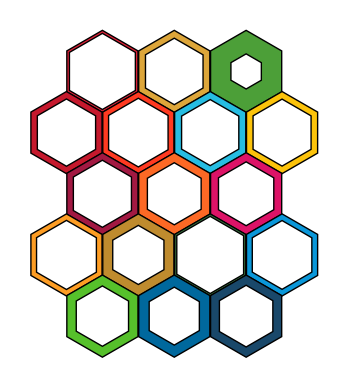

In [4]:
# Create the plot
fig, ax = plt.subplots(1)
ax.set_aspect('equal')

# Parameters for hexagon size and spacing
radius = 1  # Size of the hexagons
x_spacing = radius * 1.75  # Horizontal distance between centers of adjacent hexagons
y_spacing = np.sqrt(3) * radius * 0.86  # Vertical distance between centers of hexagons

# Add hexagons with color based on the value scaling from 0 (fully transparent) to 1 (fully SDG color)
for (x, y), value, color, label in zip(coord, sdg_goal_values, sdg_colors, labels):
    rgba_color = plt.cm.colors.to_rgba(color)  # Convert SDG color to RGBA

    # Outer hexagon for the full SDG color
    outer_hex = RegularPolygon((x * x_spacing, y * y_spacing), numVertices=6,
                               radius=radius, orientation=np.radians(0),
                               facecolor=rgba_color, edgecolor='k')

    ax.add_patch(outer_hex)

    # Inner hexagon for the percentage fill
    inner_radius = value * radius  # Scale inner radius based on the value
    inner_hex = RegularPolygon((x * x_spacing, y * y_spacing), numVertices=6,
                               radius=inner_radius, orientation=np.radians(0),
                               facecolor='white', edgecolor='k')  # White color for the inner hexagon

    ax.add_patch(inner_hex)

# Add labels to the hexagons
#for (x, y), label in zip(coord, labels):
#    ax.text(x * x_spacing, y * y_spacing, label[0],
#            horizontalalignment='center', verticalalignment='center')

plt.xlim(-4, 4)
plt.ylim(-6, 3)

plt.axis('off')
plt.savefig("average_sdg_predction_glyph.svg", transparent=True)

In [5]:
import os
os.mkdir("output")

[0.5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 0.5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 0.5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 0.5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 0.5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 0.5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 0.5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 0.5, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 0.5, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 0.5, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0.5, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0.5, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0.5, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0.5, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0.5, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0.5, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0.5]


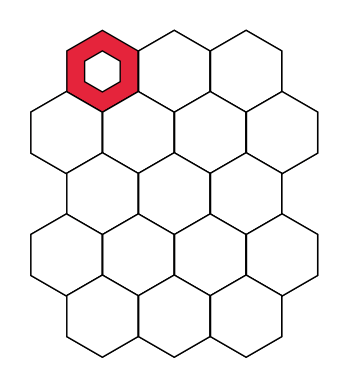

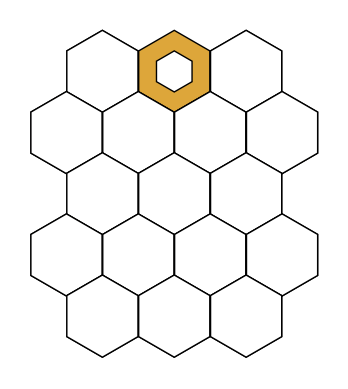

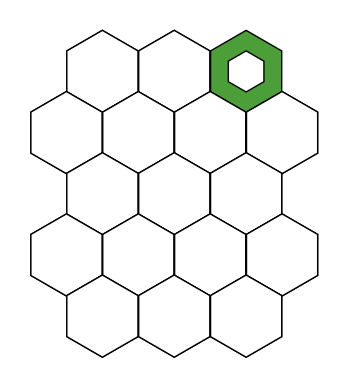

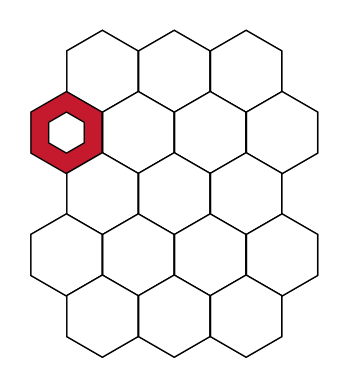

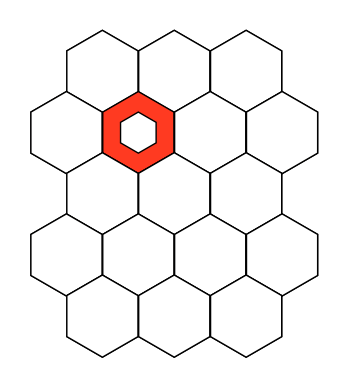

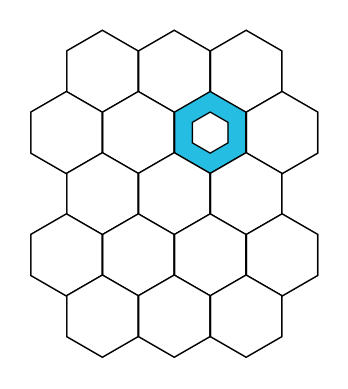

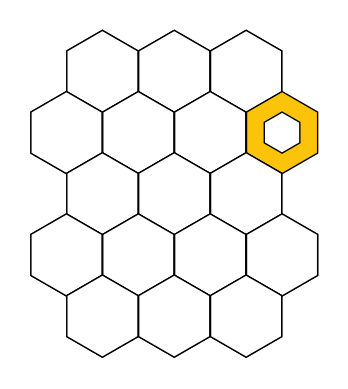

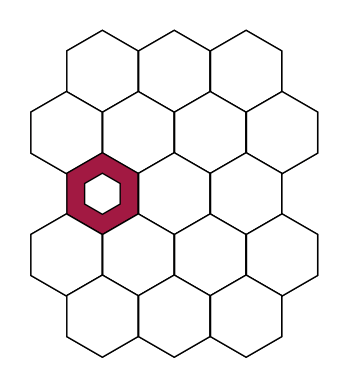

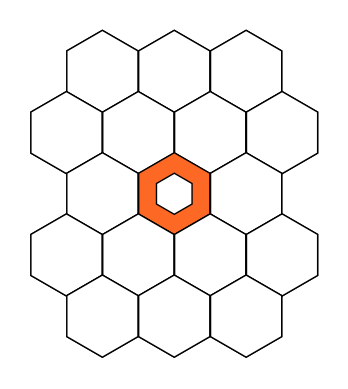

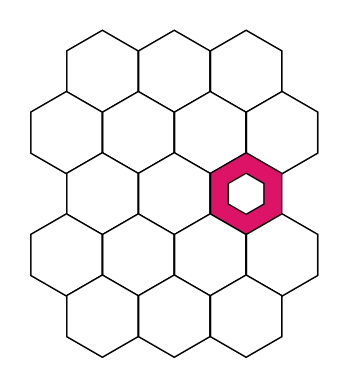

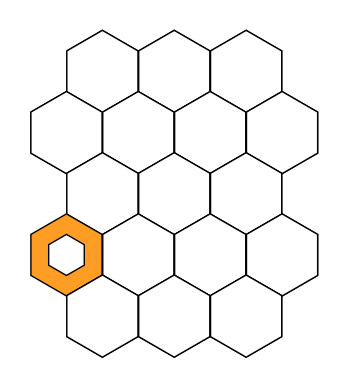

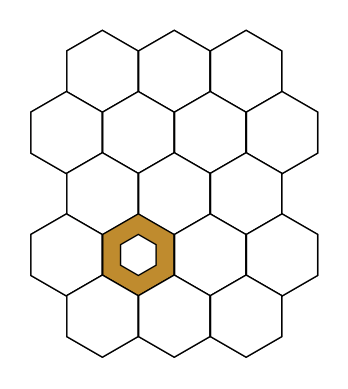

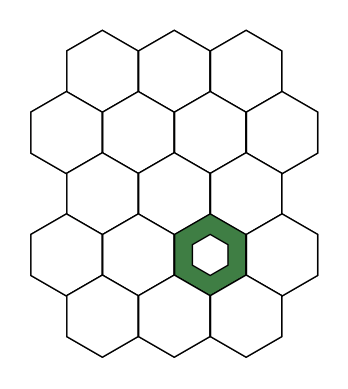

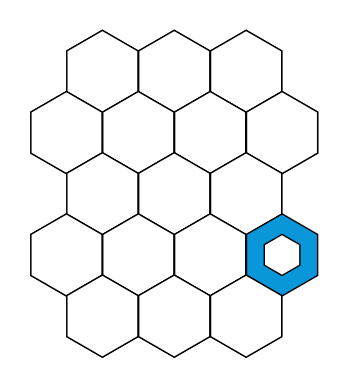

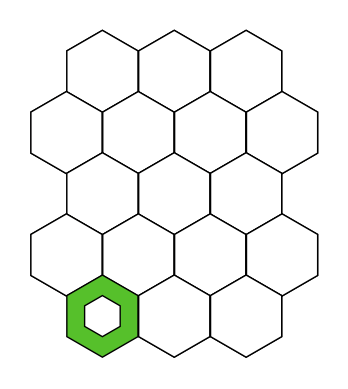

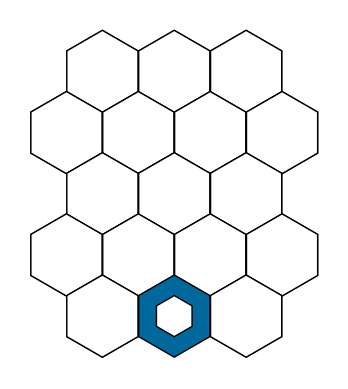

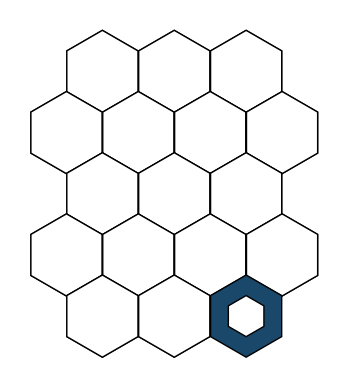

In [6]:
# Number of SDGs
num_sdgs = 17

# Create the arrays
sdg_arrays = []
for i in range(num_sdgs):
    # Create a 17-dimensional array of zeros
    sdg_array = [1] * num_sdgs
    # Set the i-th position to 0
    sdg_array[i] = 0.5
    sdg_arrays.append(sdg_array)
    print(sdg_array)

    # Create the plot
    fig, ax = plt.subplots(1)
    ax.set_aspect('equal')

    # Parameters for hexagon size and spacing
    radius = 1  # Size of the hexagons
    x_spacing = radius * 1.75  # Horizontal distance between centers of adjacent hexagons
    y_spacing = np.sqrt(3) * radius * 0.86  # Vertical distance between centers of hexagons

    # Add hexagons with color based on the value scaling from 0 (fully transparent) to 1 (fully SDG color)
    for (x, y), value, color, label in zip(coord, sdg_array, sdg_colors, labels):
        rgba_color = plt.cm.colors.to_rgba(color)  # Convert SDG color to RGBA

        # Outer hexagon for the full SDG color
        outer_hex = RegularPolygon((x * x_spacing, y * y_spacing), numVertices=6,
                                  radius=radius, orientation=np.radians(0),
                                  facecolor=rgba_color, edgecolor='k')

        ax.add_patch(outer_hex)

        # Inner hexagon for the percentage fill
        inner_radius = value * radius  # Scale inner radius based on the value
        inner_hex = RegularPolygon((x * x_spacing, y * y_spacing), numVertices=6,
                                  radius=inner_radius, orientation=np.radians(0),
                                  facecolor='white', edgecolor='k')  # White color for the inner hexagon

        ax.add_patch(inner_hex)

    # Add labels to the hexagons
    #for (x, y), label in zip(coord, labels):
    #    ax.text(x * x_spacing, y * y_spacing, label[0],
    #            horizontalalignment='center', verticalalignment='center')

    plt.xlim(-4, 4)
    plt.ylim(-6, 3)

    plt.axis('off')
    plt.savefig(f"output/sdg_{(i+1):02d}_glyph.svg", transparent=True)

In [7]:
!zip -r output/output.zip output/

  adding: output/ (stored 0%)
  adding: output/sdg_16_glyph.svg (deflated 85%)
  adding: output/sdg_02_glyph.svg (deflated 85%)
  adding: output/sdg_06_glyph.svg (deflated 85%)
  adding: output/sdg_01_glyph.svg (deflated 85%)
  adding: output/sdg_10_glyph.svg (deflated 85%)
  adding: output/sdg_05_glyph.svg (deflated 85%)
  adding: output/sdg_15_glyph.svg (deflated 85%)
  adding: output/sdg_09_glyph.svg (deflated 85%)
  adding: output/sdg_03_glyph.svg (deflated 85%)
  adding: output/sdg_08_glyph.svg (deflated 85%)
  adding: output/sdg_07_glyph.svg (deflated 85%)
  adding: output/sdg_12_glyph.svg (deflated 85%)
  adding: output/sdg_13_glyph.svg (deflated 85%)
  adding: output/sdg_04_glyph.svg (deflated 85%)
  adding: output/sdg_14_glyph.svg (deflated 85%)
  adding: output/sdg_17_glyph.svg (deflated 85%)
  adding: output/sdg_11_glyph.svg (deflated 85%)


[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]


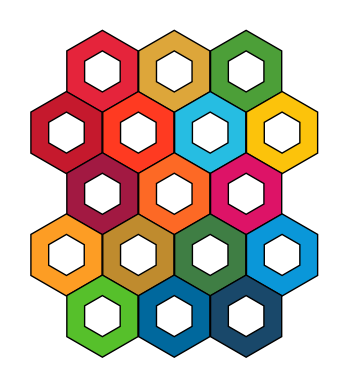

In [8]:
# Number of SDGs
num_sdgs = 17
# Create a 17-dimensional array of zeros
sdg_array = [0.5] * num_sdgs
print(sdg_array)

# Create the plot
fig, ax = plt.subplots(1)
ax.set_aspect('equal')

# Parameters for hexagon size and spacing
radius = 1  # Size of the hexagons
x_spacing = radius * 1.75  # Horizontal distance between centers of adjacent hexagons
y_spacing = np.sqrt(3) * radius * 0.86  # Vertical distance between centers of hexagons

# Add hexagons with color based on the value scaling from 0 (fully transparent) to 1 (fully SDG color)
for (x, y), value, color, label in zip(coord, sdg_array, sdg_colors, labels):
    rgba_color = plt.cm.colors.to_rgba(color)  # Convert SDG color to RGBA

    # Outer hexagon for the full SDG color
    outer_hex = RegularPolygon((x * x_spacing, y * y_spacing), numVertices=6,
                              radius=radius, orientation=np.radians(0),
                              facecolor=rgba_color, edgecolor='k')

    ax.add_patch(outer_hex)

    # Inner hexagon for the percentage fill
    inner_radius = value * radius  # Scale inner radius based on the value
    inner_hex = RegularPolygon((x * x_spacing, y * y_spacing), numVertices=6,
                              radius=inner_radius, orientation=np.radians(0),
                              facecolor='white', edgecolor='k')  # White color for the inner hexagon

    ax.add_patch(inner_hex)

# Add labels to the hexagons
#for (x, y), label in zip(coord, labels):
#    ax.text(x * x_spacing, y * y_spacing, label[0],
#            horizontalalignment='center', verticalalignment='center')

plt.xlim(-4, 4)
plt.ylim(-6, 3)

plt.axis('off')
plt.savefig(f"output/sdg_loader_glyph.svg", transparent=True)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import matplotlib.colors as mcolors

# Number of SDGs
num_sdgs = 17

# Define SDG colors (example colors, replace with actual SDG colors)
sdg_colors = [
    "#E5243B", "#DDA63A", "#4C9F38", "#C5192D", "#FF3A21",
    "#26BDE2", "#FCC30B", "#A21942", "#FD6925", "#DD1367",
    "#FD9D24", "#BF8B2E", "#3F7E44", "#0A97D9", "#56C02B",
    "#00689D", "#19486A"
]

# Coordinates for placing a single hexagon at the origin
coord = [(0, 0)]  # Center hexagon

# Create and save plots for each SDG with three levels (0, 0.25, 0.5, 0.75)
for i in range(num_sdgs):
    for level, value in enumerate([0, 0.25, 0.5, 0.75, 1], start=1):
        # Create the plot
        fig, ax = plt.subplots(1)
        ax.set_aspect('equal')

        # Parameters for hexagon size
        radius = 1

        # Add hexagons with color based on the value
        for (x, y), color in zip(coord, [sdg_colors[i]]):
            rgba_color = mcolors.to_rgba(color)  # Convert SDG color to RGBA

            # Outer hexagon for the full SDG color
            outer_hex = RegularPolygon((x, y), numVertices=6,
                                        radius=radius, orientation=np.radians(0),
                                        facecolor=rgba_color, edgecolor='k')
            ax.add_patch(outer_hex)

            # Inner hexagon for the percentage fill
            inner_radius = value * radius  # Scale inner radius based on the value
            inner_hex = RegularPolygon((x, y), numVertices=6,
                                        radius=inner_radius, orientation=np.radians(0),
                                        facecolor='white', edgecolor='k')
            ax.add_patch(inner_hex)

        # Set limits and remove axes
        ax.set_xlim(-2, 2)
        ax.set_ylim(-2, 2)
        ax.axis('off')

        # Save the figure
        plt.savefig(f"output2/simple/{level}/sdg_{i + 1:02d}_level_{level}_glyph.svg", transparent=True)
        plt.close(fig)

print("Hexagons for SDGs at multiple levels saved as SVG files.")

Hexagons for SDGs at multiple levels saved as SVG files.


In [18]:
!zip -r output2/simple.zip output2/simple/

  adding: output2/simple/ (stored 0%)
  adding: output2/simple/4/ (stored 0%)
  adding: output2/simple/4/sdg_13_level_4_glyph.svg (deflated 53%)
  adding: output2/simple/4/sdg_02_level_4_glyph.svg (deflated 53%)
  adding: output2/simple/4/sdg_12_level_4_glyph.svg (deflated 53%)
  adding: output2/simple/4/sdg_07_level_4_glyph.svg (deflated 53%)
  adding: output2/simple/4/sdg_04_level_4_glyph.svg (deflated 53%)
  adding: output2/simple/4/sdg_01_level_4_glyph.svg (deflated 53%)
  adding: output2/simple/4/sdg_06_level_4_glyph.svg (deflated 53%)
  adding: output2/simple/4/sdg_14_level_4_glyph.svg (deflated 53%)
  adding: output2/simple/4/sdg_09_level_4_glyph.svg (deflated 53%)
  adding: output2/simple/4/sdg_10_level_4_glyph.svg (deflated 53%)
  adding: output2/simple/4/sdg_17_level_4_glyph.svg (deflated 53%)
  adding: output2/simple/4/sdg_05_level_4_glyph.svg (deflated 53%)
  adding: output2/simple/4/sdg_15_level_4_glyph.svg (deflated 53%)
  adding: output2/simple/4/sdg_08_level_4_glyph.svg

In [13]:
!zip -r output/simple.zip output/simple/

  adding: output/simple/ (stored 0%)
  adding: output/simple/sdg_02_level_3_glyph.svg (deflated 53%)
  adding: output/simple/sdg_15_level_2_glyph.svg (deflated 54%)
  adding: output/simple/sdg_14_level_2_glyph.svg (deflated 54%)
  adding: output/simple/sdg_11_level_1_glyph.svg (deflated 53%)
  adding: output/simple/sdg_05_level_3_glyph.svg (deflated 53%)
  adding: output/simple/sdg_09_level_1_glyph.svg (deflated 53%)
  adding: output/simple/sdg_01_level_3_glyph.svg (deflated 53%)
  adding: output/simple/sdg_16_level_2_glyph.svg (deflated 54%)
  adding: output/simple/sdg_08_level_2_glyph.svg (deflated 54%)
  adding: output/simple/sdg_17_level_1_glyph.svg (deflated 53%)
  adding: output/simple/sdg_11_level_2_glyph.svg (deflated 54%)
  adding: output/simple/sdg_05_level_1_glyph.svg (deflated 53%)
  adding: output/simple/sdg_16_level_1_glyph.svg (deflated 53%)
  adding: output/simple/sdg_12_level_1_glyph.svg (deflated 53%)
  adding: output/simple/sdg_03_level_1_glyph.svg (deflated 53%)
  a